# KinC_x60_4b: data versus smeared SIMC yields

This notebook compares the **measured mass-based pi0 yield** with smeared
SIMC. Missing-mass plots display all valid events across 0-2.5 GeV; the
1.10 GeV line only marks a proposed high-side boundary. It does not select
events in this notebook. The exclusive SIMC template is peak-normalized;
a two-scale fit adjusts SIDIS and Delta to the weighted data histogram. The
exclusive scale is fixed by matching the highest bin in the proton peak;
SIDIS and Delta scales then fit the remaining full-range distribution. It does
not use the hydrogen yield factor. The upper bound is a *diagnostic*;
any excess beyond the exclusive SIMC template may include SIDIS, Delta,
accidentals, or an acceptance/radiation mismatch. Shape agreement alone
does not establish a Born cross section.

Both inputs and all normalization factors are shown below. The notebook
reads files only and does not overwrite analysis products.



In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
from itertools import combinations
from IPython.display import display

DATA_FILE = Path('/w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main/output/KinC_x60_4b/root/combined_branches_LH2.root')
SIMC_FILE = Path('/lustre24/expphy/volatile/hallc/nps/singhav/nps_smearing/smear_x60_4b_test/smearing_output/KinC_x60_4b/root/simc_pi0_analysis_output_smeared.root')
MMISS_UPPER_GEV = 1.10  # Editable test boundary; inspect scans before fixing it.
APPLY_XSEC_KINEMATICS = False  # Default: all valid candidates. True uses extractor Q2/xB/t' range.
MASS_EDGES = np.linspace(0.0, 2.5, 251)  # Covers observed positive data/MC maxima, 2.461/2.404 GeV.
PEAK_WINDOW_GEV = (0.90, 1.02)  # Includes the observed data/MC peak near 0.955 GeV.

assert DATA_FILE.is_file() and SIMC_FILE.is_file(), 'Check the two input paths.'



In [ ]:
# Read only branches needed for yield comparison. Data mmiss_all and SIMC
# mmiss are the reconstructed missing-mass observables used in the high-side
# selection line; no exclusivity flag is applied in this notebook. Data and
# SIMC generated-channel labels differ, so only the latter separates MC
# templates for visualization.
data_names = ['mmiss_all', 'pi0_weight', 'scale',
              'charge_uC', 'run_number', 'Q2', 'xB', 't', 'tmin']
sim_names = ['mmiss', 'full_weight', 'sigcm', 'is_exclusive',
             'is_sidis', 'is_delta', 'Q2', 'xB', 't', 'tmin']
with uproot.open(DATA_FILE) as f:
    d = f['physics'].arrays(data_names, library='np')
with uproot.open(SIMC_FILE) as f:
    s = f['simulation'].arrays(sim_names, library='np')

# The combined data tree repeats run charge on every event. Sum each run's
# charge once, then multiply its existing PS/(LT*eff*Q_run) scale by
# Q_run/Q_total. This gives corrected counts/mC before any hydrogen-yield
# factor; no target correction is applied in this diagnostic fit.
runs, first = np.unique(d['run_number'], return_index=True)
run_charges = d['charge_uC'][first].astype(float)
valid_charges = np.isfinite(run_charges) & (run_charges > 0)
assert np.all(valid_charges), f'Invalid run charges: {runs[~valid_charges]}'
total_charge_uC = run_charges.sum()
dw = (d['pi0_weight'].astype(float) * d['scale'].astype(float) *
      d['charge_uC'].astype(float) / total_charge_uC)
sw = s['full_weight'].astype(float)  # Includes SIMC normfac/Ngen; no /sigcm for yield overlays.

def physics_mask(a):
    if not APPLY_XSEC_KINEMATICS:
        return np.ones(len(a['Q2']), dtype=bool)
    tp = a['t'] - a['tmin']
    return ((a['Q2'] >= 5.1) & (a['Q2'] <= 6.4) &
            (a['xB'] >= 0.45) & (a['xB'] <= 0.65) &
            (tp >= -1.0) & (tp <= 0.0))

dvalid = physics_mask(d) & np.isfinite(d['mmiss_all']) & (d['mmiss_all'] > 0) & np.isfinite(dw)
svalid = physics_mask(s) & np.isfinite(s['mmiss']) & (s['mmiss'] > 0) & np.isfinite(sw)
assert np.max(d['mmiss_all'][dvalid]) <= MASS_EDGES[-1], 'Extend MASS_EDGES to include all valid data.'
assert np.max(s['mmiss'][svalid]) <= MASS_EDGES[-1], 'Extend MASS_EDGES to include all valid SIMC.'
print(f'Data entries: {len(dw):,}; SIMC entries: {len(sw):,}; total data charge: {total_charge_uC/1000:.6g} mC')
print(f'Valid candidates in chosen kinematic domain: data {dvalid.sum():,}, SIMC {svalid.sum():,}')
zero_sigcm = svalid & (s['is_exclusive'] != 0) & np.isfinite(s['sigcm']) & (np.abs(s['sigcm']) < 1e-20)
print(f'Exclusive SIMC with unusable sigcm in chosen domain: {zero_sigcm.sum():,}')



Data entries: 1,039,581; SIMC entries: 1,207,304; total data charge: 2500.06 mC
Valid candidates in chosen kinematic domain: data 1,035,479, SIMC 1,207,304
Exclusive SIMC with unusable sigcm in chosen domain: 0


In [ ]:
# Keep the generated exclusive channel separate from simulated SIDIS/Delta.
# All three channels are plotted over the full range; these labels split MC
# templates for display and do not gate data or apply the proposed high cut.
channel_masks = {
    'exclusive SIMC': s['is_exclusive'] != 0,
    'SIDIS SIMC': s['is_sidis'] != 0,
    'Delta SIMC': s['is_delta'] != 0,
}



Peak window: 0.90-1.02 GeV; data peak 0.955 GeV (0.830998/bin); exclusive SIMC peak 0.955 GeV (4.11351/bin)
Exclusive peak normalization: 0.202017; peak positions differ by 0.000 GeV


,component,fitted_scale,scale_rule,original_yield,fitted_yield
0,exclusive SIMC,0.2020,data/exclusive peak bin,68.6190,13.8622
1,SIDIS SIMC,0.6677,full-range NNLS,96.8224,64.6525
2,Delta SIMC,0.0000,full-range NNLS,9.3004,0.0000


Weighted residual score / used bin: 154.7 (245 bins, one peak-fixed and two fitted scales; not a Poisson chi-square)


,component,yield_0_to_2p5_GeV,stat_sumw2
0,data,90.7577,0.1525
1,exclusive SIMC,68.6190,0.1163
2,SIDIS SIMC,96.8224,0.1834
3,Delta SIMC,9.3004,0.0167
4,all SIMC,174.7419,0.2178


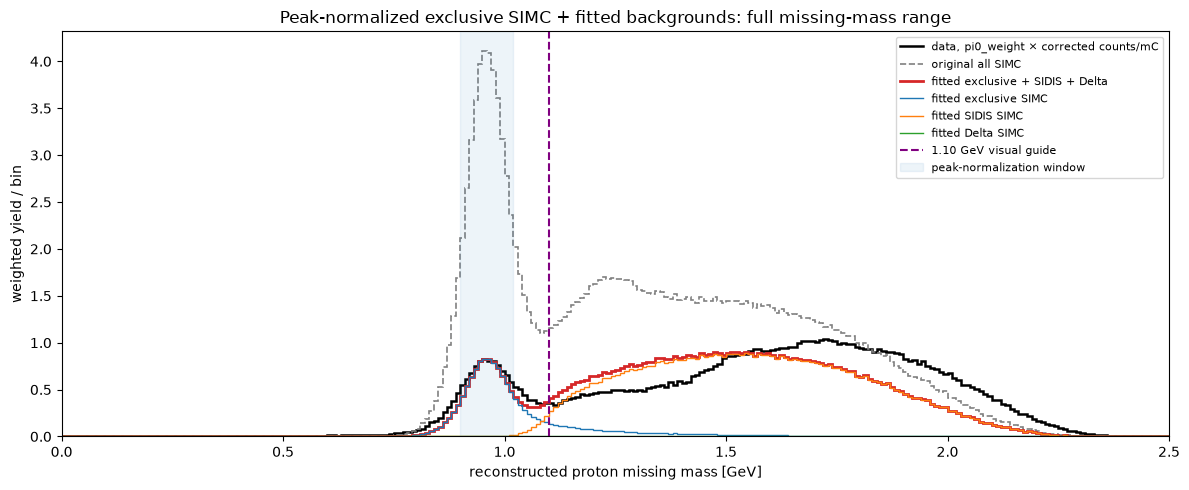

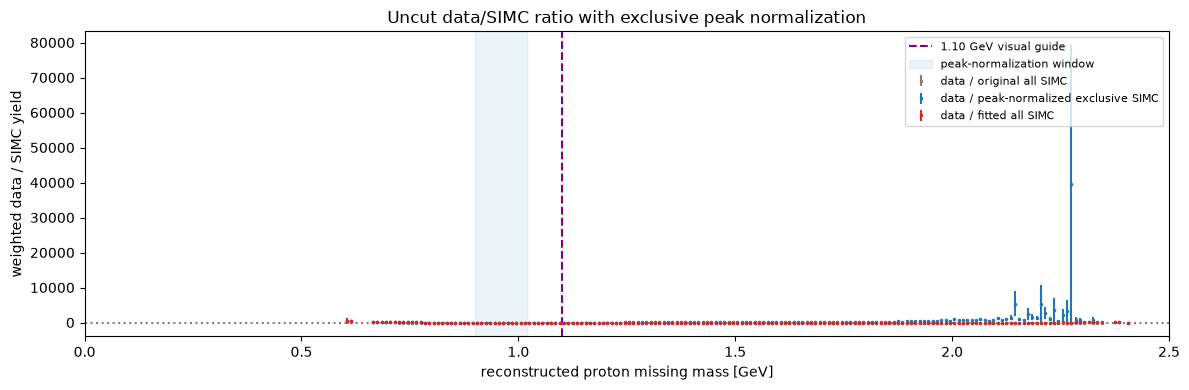

In [ ]:
# The primary comparison deliberately applies NO MCD or missing-mass upper
# cut. The line at 1.10 GeV is visual only: curves continue through 2.5 GeV.
# Optional APPLY_XSEC_KINEMATICS controls only Q2, xB and t' population.
data_hist = np.histogram(d['mmiss_all'][dvalid], MASS_EDGES, weights=dw[dvalid])[0]
data_var = np.histogram(d['mmiss_all'][dvalid], MASS_EDGES, weights=np.square(dw[dvalid]))[0]
sim_hists = {}
sim_vars = {}
for label, channel in channel_masks.items():
    mask = svalid & channel
    sim_hists[label] = np.histogram(s['mmiss'][mask], MASS_EDGES, weights=sw[mask])[0]
    sim_vars[label] = np.histogram(s['mmiss'][mask], MASS_EDGES, weights=np.square(sw[mask]))[0]
all_sim_hist = sum(sim_hists.values())
all_sim_var = sum(sim_vars.values())
centers = 0.5 * (MASS_EDGES[:-1] + MASS_EDGES[1:])

# Minimal template fit: fix the exclusive scale by the highest data/SIMC
# bin within a proton-peak window, then fit two nonnegative background scales.
# This is a visual normalization, not an absolute exclusive cross section:
# measured data in that bin can include background. Every positive-variance
# mass bin in the full 0-2.5 GeV range participates in the background fit;
# the 1.10 GeV line has no fit effect.
# Data and MC are weighted sums, so sumw2 supplies a variance estimate.
# Because MC variance changes as a channel is scaled, repeat NNLS with the
# current scale-dependent variance. This is still a diagnostic template fit:
# background factors can absorb model, acceptance, or background mismatches and
# are not measurements of channel cross sections.
component_names = list(sim_hists)
design = np.column_stack([sim_hists[name] for name in component_names])
component_vars = np.column_stack([sim_vars[name] for name in component_names])

def nnls_small(matrix, target):
    # Enumerate all active channel sets. Solve least squares within each set
    # and retain the lowest-residual nonnegative solution. For the two
    # background templates this is exact NNLS and needs only NumPy.
    ncols = matrix.shape[1]
    best = np.zeros(ncols)
    best_loss = float(np.square(target).sum())
    for count in range(1, ncols + 1):
        for active in combinations(range(ncols), count):
            trial_active = np.linalg.lstsq(matrix[:, active], target, rcond=None)[0]
            if np.any(trial_active < -1e-12):
                continue
            trial = np.zeros(ncols)
            trial[list(active)] = np.maximum(0.0, trial_active)
            loss = float(np.square(matrix @ trial - target).sum())
            if loss < best_loss:
                best, best_loss = trial, loss
    return best

peak_bins = (centers >= PEAK_WINDOW_GEV[0]) & (centers <= PEAK_WINDOW_GEV[1])
assert np.any(peak_bins), 'Peak window misses the histogram bin centers.'
peak_indices = np.flatnonzero(peak_bins)
data_peak_bin = peak_indices[np.argmax(data_hist[peak_bins])]
sim_peak_bin = peak_indices[np.argmax(sim_hists['exclusive SIMC'][peak_bins])]
data_peak_height = data_hist[data_peak_bin]
sim_peak_height = sim_hists['exclusive SIMC'][sim_peak_bin]
assert sim_peak_height > 0 and data_peak_height > 0, 'Proton peak requires positive weighted yields.'
peak_scale = data_peak_height / sim_peak_height
print(f'Peak window: {PEAK_WINDOW_GEV[0]:.2f}-{PEAK_WINDOW_GEV[1]:.2f} GeV; '
      f'data peak {centers[data_peak_bin]:.3f} GeV ({data_peak_height:.6g}/bin); '
      f'exclusive SIMC peak {centers[sim_peak_bin]:.3f} GeV ({sim_peak_height:.6g}/bin)')
print(f'Exclusive peak normalization: {peak_scale:.6g}; '
      f'peak positions differ by {abs(centers[data_peak_bin]-centers[sim_peak_bin]):.3f} GeV')

# Keep the exclusive peak scale fixed. Fit SIDIS and Delta to the residual
# data after subtracting that exclusive template, using data and scaled MC
# sumw2 in each bin. The residual can be negative; NNLS constrains only the
# two background scales. Reweight four times because MC variance depends on
# the trial scales. This uses the full mass histogram, including the peak.
scales = np.array([peak_scale, 1.0, 1.0])
for _ in range(4):
    fit_variance = data_var + component_vars @ np.square(scales)
    fit_bins = np.isfinite(fit_variance) & (fit_variance > 0) & np.isfinite(data_hist)
    sigma = np.sqrt(fit_variance[fit_bins])
    residual = data_hist[fit_bins] - peak_scale * design[fit_bins, 0]
    background_scales = nnls_small(design[fit_bins, 1:] / sigma[:, None], residual / sigma)
    scales = np.r_[peak_scale, background_scales]
fitted_hists = {name: scales[i] * sim_hists[name] for i, name in enumerate(component_names)}
fitted_total = design @ scales
fitted_var = component_vars @ np.square(scales)
fit_variance = data_var + fitted_var
fit_bins = np.isfinite(fit_variance) & (fit_variance > 0) & np.isfinite(data_hist)
weighted_residual = np.sum(np.square(data_hist[fit_bins] - fitted_total[fit_bins]) /
                           fit_variance[fit_bins])
fit_table = pd.DataFrame({
    'component': component_names,
    'fitted_scale': scales,
    'scale_rule': ['data/exclusive peak bin', 'full-range NNLS', 'full-range NNLS'],
    'original_yield': [sim_hists[name].sum() for name in component_names],
    'fitted_yield': [fitted_hists[name].sum() for name in component_names],
})
display(fit_table.round(4))
print(f'Weighted residual score / used bin: {weighted_residual/fit_bins.sum():.4g} '
      f'({fit_bins.sum()} bins, one peak-fixed and two fitted scales; not a Poisson chi-square)')

full_range_yields = pd.DataFrame({
    'component': ['data', 'exclusive SIMC', 'SIDIS SIMC', 'Delta SIMC', 'all SIMC'],
    'yield_0_to_2p5_GeV': [data_hist.sum(), *(h.sum() for h in sim_hists.values()), all_sim_hist.sum()],
    'stat_sumw2': [np.sqrt(data_var.sum()), *(np.sqrt(v.sum()) for v in sim_vars.values()),
                   np.sqrt(all_sim_var.sum())],
})
display(full_range_yields.round(4))

fig, ax = plt.subplots(figsize=(12, 5))
ax.stairs(data_hist, MASS_EDGES, label='data, pi0_weight × corrected counts/mC', color='black', linewidth=1.8)
ax.stairs(all_sim_hist, MASS_EDGES, label='original all SIMC', color='gray', linewidth=1.2, linestyle='--')
ax.stairs(fitted_total, MASS_EDGES, label='fitted exclusive + SIDIS + Delta', color='tab:red', linewidth=2)
for label, color in [('exclusive SIMC', 'tab:blue'), ('SIDIS SIMC', 'tab:orange'), ('Delta SIMC', 'tab:green')]:
    ax.stairs(fitted_hists[label], MASS_EDGES, label=f'fitted {label}', color=color)
ax.axvline(MMISS_UPPER_GEV, ls='--', color='purple', label=f'{MMISS_UPPER_GEV:.2f} GeV visual guide')
ax.axvspan(*PEAK_WINDOW_GEV, color='tab:blue', alpha=0.08, label='peak-normalization window')
ax.set(xlim=(MASS_EDGES[0], MASS_EDGES[-1]),
       xlabel='reconstructed proton missing mass [GeV]', ylabel='weighted yield / bin',
       title='Peak-normalized exclusive SIMC + fitted backgrounds: full missing-mass range')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# Ratio uses the same uncut histograms. Weighted-event sumw2 gives a rough
# per-bin statistical error; common charge, target and model uncertainties
# remain correlated and are not represented by these bars.
def ratio_with_stat(sim_hist, sim_var):
    good = sim_hist > 0
    ratio = np.full_like(sim_hist, np.nan, dtype=float)
    error = np.full_like(sim_hist, np.nan, dtype=float)
    ratio[good] = data_hist[good] / sim_hist[good]
    error[good] = np.sqrt(data_var[good] / sim_hist[good]**2 +
                          data_hist[good]**2 * sim_var[good] / sim_hist[good]**4)
    return ratio, error

fig, ax = plt.subplots(figsize=(12, 4))
for label, hist, var, color in [
    ('data / original all SIMC', all_sim_hist, all_sim_var, 'gray'),
    ('data / peak-normalized exclusive SIMC', fitted_hists['exclusive SIMC'],
     scales[0]**2 * sim_vars['exclusive SIMC'], 'tab:blue'),
    ('data / fitted all SIMC', fitted_total, fitted_var, 'tab:red')]:
    ratio, error = ratio_with_stat(hist, var)
    ax.errorbar(centers, ratio, yerr=error, fmt='.', ms=3, capsize=0, color=color, label=label)
ax.axvline(MMISS_UPPER_GEV, ls='--', color='purple', label=f'{MMISS_UPPER_GEV:.2f} GeV visual guide')
ax.axvspan(*PEAK_WINDOW_GEV, color='tab:blue', alpha=0.08, label='peak-normalization window')
ax.axhline(1.0, ls=':', color='gray')
ax.set(xlim=(MASS_EDGES[0], MASS_EDGES[-1]),
       xlabel='reconstructed proton missing mass [GeV]', ylabel='weighted data / SIMC yield',
       title='Uncut data/SIMC ratio with exclusive peak normalization')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
